# Nạp thư viện

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

# Đọc dữ liệu MNIST

In [ ]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(19999, 785)
(19999, 784)
(19999,)
(9999, 784)
(9999,)


In [ ]:
num_classes = 10
input_shape = (28,28,1)
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

# Convert to numpy arrays if they are not already
if not isinstance(X_train, np.ndarray):
    X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0],28,28,1)
print(X_train.shape)

if not isinstance(X_test, np.ndarray):
    X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0],28,28,1)
print(X_test.shape)

print('Number of classes:',len(np.unique(y_train)))
print('Classes:',np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


# Trực quan hóa 10 ảnh đàu tiên

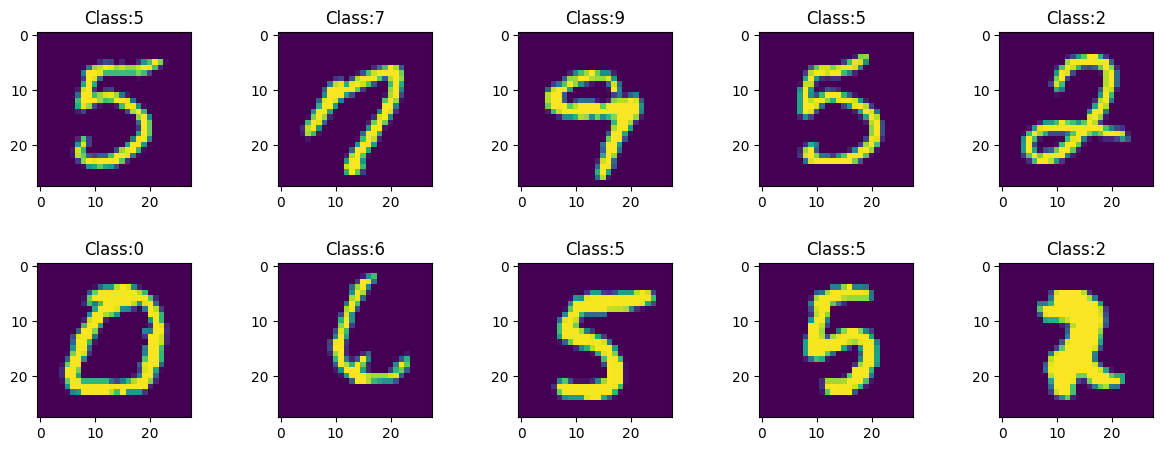

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28,28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace = 0.5)
plt.show()

# Chuyển giá trị nhãn thành one-hot encoding

In [ ]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


# Xây dựng mô hình CNN

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

# Huấn luyện mô hình CNN

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.8373 - loss: 0.5950 - val_accuracy: 0.9365 - val_loss: 0.2038
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.9563 - loss: 0.1485 - val_accuracy: 0.9650 - val_loss: 0.1262
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.9712 - loss: 0.0968 - val_accuracy: 0.9680 - val_loss: 0.1058
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9771 - loss: 0.0744 - val_accuracy: 0.9720 - val_loss: 0.0931
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.9820 - loss: 0.0612 - val_accuracy: 0.9775 - val_loss: 0.0813
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.9849 - loss: 0.0491 - val_accuracy: 0.9795 - val_loss: 0.0717
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.9863 - loss: 0.0429 - val_accuracy: 0.9770 - val_loss: 0.0766
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.9887 - loss: 0.0364 -

# Đánh giá mô hình CNN

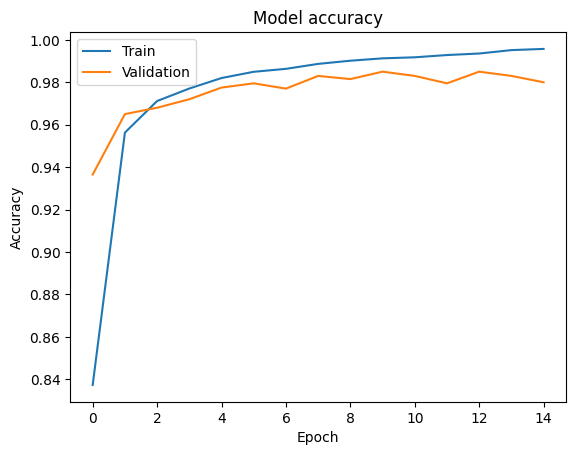

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

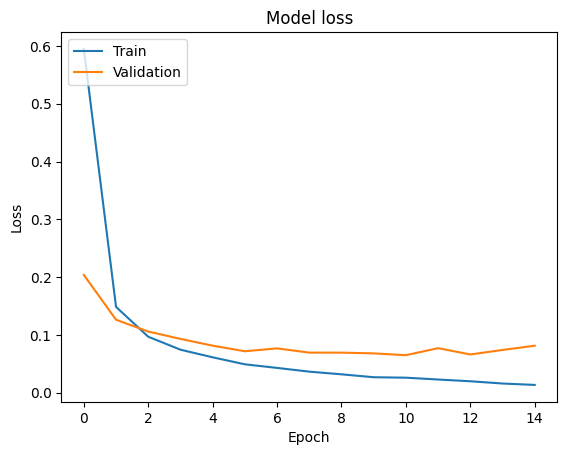

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Đánh giá mô hình CNN thử nghiệm trên tập test

In [ ]:
score = model.evaluate(X_test, y_test, verbose = 2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 8ms/step - accuracy: 0.9841 - loss: 0.0584
Test loss: 0.05839809402823448
Test accuracy: 0.9840984344482422


# Dự báo nhãn cho ảnh sử dụng CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[[1.3828274e-07 8.0832391e-04 9.9919158e-01 3.4214697e-11 1.6184718e-17
  4.3454925e-15 3.1332354e-09 2.7732353e-17 1.0205177e-10 2.6827860e-20]]
<function argmax at 0x7d8ced951b20> 2


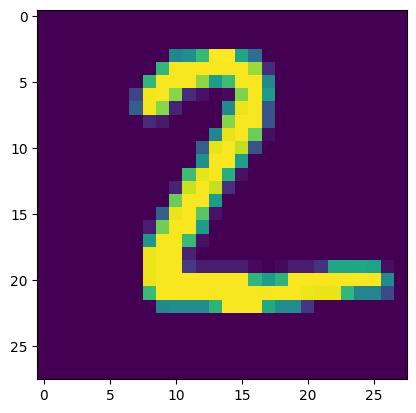

In [ ]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax, np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28,28))
plt.show()

# Lưu tham số mô hình CNN

In [ ]:
model.save_weights('model_cnn.weights.h5')

# Nạp lại mô hình và tham số

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[6.1242349e-09 9.9991107e-01 1.8708242e-05 6.9753689e-08 5.9422982e-05
  5.9545368e-08 3.5295571e-07 7.4556542e-06 2.9992250e-06 9.5922670e-10]]
<function argmax at 0x7d8ced951b20> 1


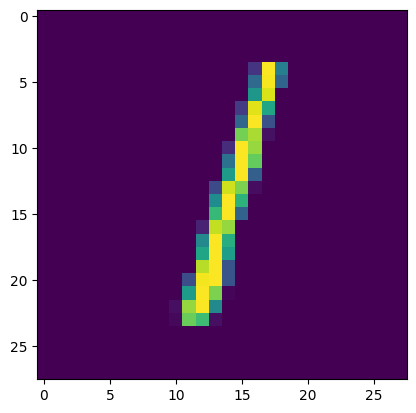

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('model_cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax, np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28,28))
plt.show()

### Đánh giá mô hình bằng Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


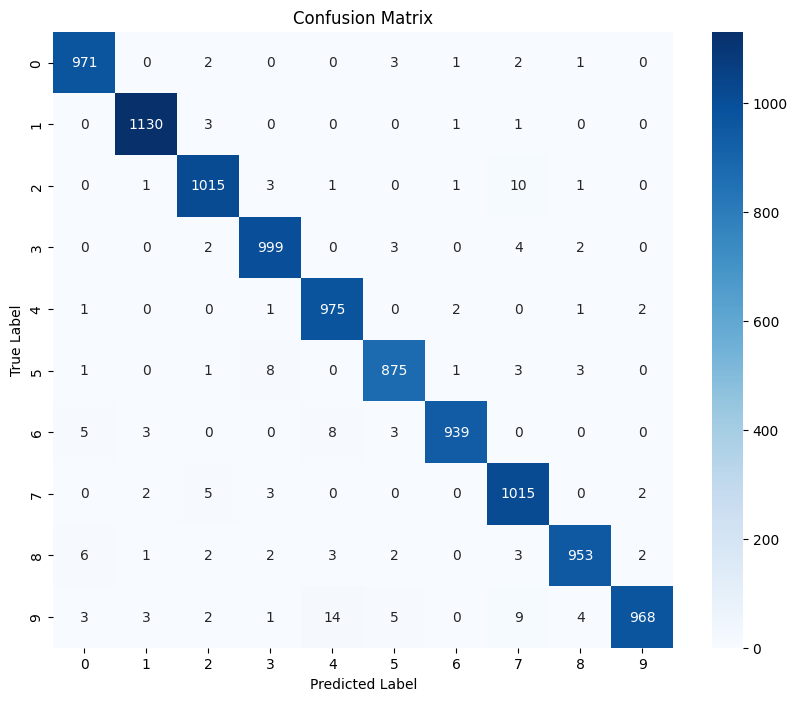

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for the test set
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()